In [1]:
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
device = torch.device(
                    "cuda"
                    if torch.cuda.is_available()
                    else "mps" if torch.backends.mps.is_available() else "cpu"
                )
print(f"Using {device}")

# load & preprocess
data = sio.loadmat('../data/mine_impact_data_2019.mat')
samps = pd.DataFrame(data['x'].T)
labs  = pd.DataFrame(data['y'].T, columns=['y'])
df = pd.concat([samps, labs], axis=1).dropna().sample(frac=1, random_state=42)


Using mps


In [3]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data = Extract_Features(df_X, df_Y, feature="raw")

# # Function to Shifting Time
# def manipulate(data, sampling_rate=48000, shift_max=0.1, shift_direction = "both"):
#     shift = np.random.randint(sampling_rate * shift_max)
#     if shift_direction == 'right':
#         shift = -shift
#     elif shift_direction == 'both':
#         direction = np.random.randint(0, 2)
#         if direction == 1:
#             shift = -shift
#     augmented_data = np.roll(data, shift)
#     # Set to silence for heading/ tailing
#     if shift > 0:
#         augmented_data[:shift] = 0
#     else:
#         augmented_data[shift:] = 0
#     return augmented_data

# def manipulate(data, noise_factor=0.1):
#     noise = np.random.randn(len(data))
#     augmented_data = data + noise_factor * noise
#     # Cast back to same data type
#     augmented_data = augmented_data.astype(type(data[0]))
#     return augmented_data

# import librosa
# def manipulate(data, sampling_rate=48000, pitch_factor=0.1):
#     return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# # Randomly select 10% of row indices
# num_rows = data.get_samples().shape[0]
# frac = 0.1
# selected_idx = np.random.choice(num_rows, size=int(num_rows * frac), replace=False)

# # Apply the function in-place to selected rows
# data.X_reduced[selected_idx] = np.array([manipulate(data.X_reduced[i]) for i in selected_idx])


print(data.get_samples().shape, data.get_labels().shape)

(3309, 36000) (3309,)


[INFO] EPOCH: 1/50
Train loss: 0.641899, Train accuracy: 0.6628
Val loss: 0.802957, Val accuracy: 0.6600

[INFO] EPOCH: 2/50
Train loss: 0.575279, Train accuracy: 0.6631
Val loss: 0.641425, Val accuracy: 0.6600

[INFO] EPOCH: 3/50
Train loss: 0.492642, Train accuracy: 0.7555
Val loss: 0.586172, Val accuracy: 0.7900

[INFO] EPOCH: 4/50
Train loss: 0.419707, Train accuracy: 0.8200
Val loss: 0.507974, Val accuracy: 0.8600

[INFO] EPOCH: 5/50
Train loss: 0.332579, Train accuracy: 0.8562
Val loss: 0.334358, Val accuracy: 0.8800

[INFO] EPOCH: 6/50
Train loss: 0.267845, Train accuracy: 0.8852
Val loss: 0.307079, Val accuracy: 0.9200

[INFO] EPOCH: 7/50
Train loss: 0.248695, Train accuracy: 0.9007
Val loss: 0.277494, Val accuracy: 0.9100

[INFO] EPOCH: 8/50
Train loss: 0.203663, Train accuracy: 0.9162
Val loss: 0.311452, Val accuracy: 0.9200

[INFO] EPOCH: 9/50
Train loss: 0.189792, Train accuracy: 0.9197
Val loss: 0.211731, Val accuracy: 0.9300

[INFO] EPOCH: 10/50
Train loss: 0.173128, Trai

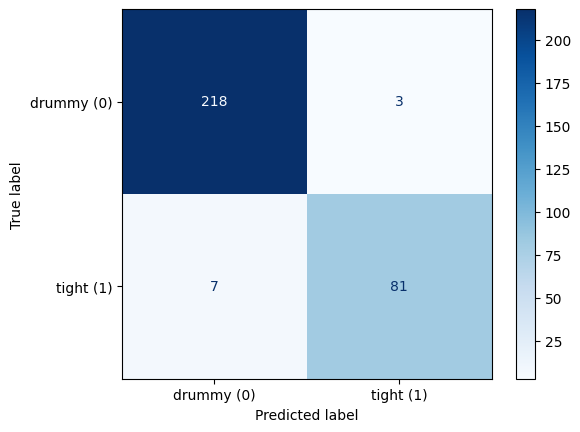


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.97      0.99      0.98       221
   tight (1)       0.96      0.92      0.94        88

    accuracy                           0.97       309
   macro avg       0.97      0.95      0.96       309
weighted avg       0.97      0.97      0.97       309



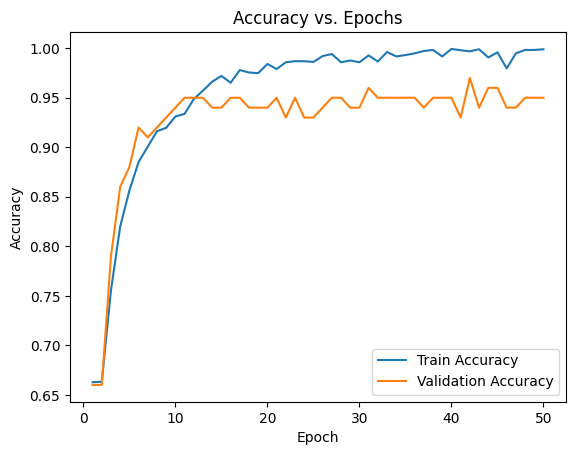

In [6]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 2900))
val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
val_data = torch.utils.data.Subset(data, val_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()
epochs = 50

history = loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader,val=True, val_loader = val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

[INFO] EPOCH: 1/25
Train loss: 0.644872, Train accuracy: 0.6617
[INFO] EPOCH: 2/25
Train loss: 0.546895, Train accuracy: 0.6737
[INFO] EPOCH: 3/25
Train loss: 0.437222, Train accuracy: 0.8140
[INFO] EPOCH: 4/25
Train loss: 0.323076, Train accuracy: 0.8717
[INFO] EPOCH: 5/25
Train loss: 0.251395, Train accuracy: 0.9040
[INFO] EPOCH: 6/25
Train loss: 0.215112, Train accuracy: 0.9210
[INFO] EPOCH: 7/25
Train loss: 0.176830, Train accuracy: 0.9347
[INFO] EPOCH: 8/25
Train loss: 0.149444, Train accuracy: 0.9480
[INFO] EPOCH: 9/25
Train loss: 0.127408, Train accuracy: 0.9583
[INFO] EPOCH: 10/25
Train loss: 0.105973, Train accuracy: 0.9640
[INFO] EPOCH: 11/25
Train loss: 0.099290, Train accuracy: 0.9663
[INFO] EPOCH: 12/25
Train loss: 0.068260, Train accuracy: 0.9770
[INFO] EPOCH: 13/25
Train loss: 0.066869, Train accuracy: 0.9773
[INFO] EPOCH: 14/25
Train loss: 0.053182, Train accuracy: 0.9833
[INFO] EPOCH: 15/25
Train loss: 0.045244, Train accuracy: 0.9847
[INFO] EPOCH: 16/25
Train loss: 0.

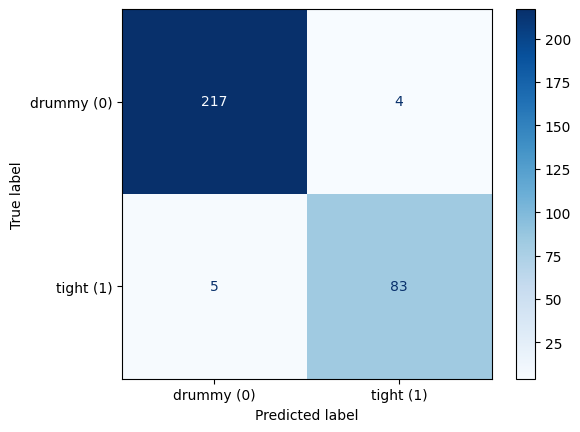


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.98      0.98      0.98       221
   tight (1)       0.95      0.94      0.95        88

    accuracy                           0.97       309
   macro avg       0.97      0.96      0.96       309
weighted avg       0.97      0.97      0.97       309



In [5]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 3000))
# val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
# val_data = torch.utils.data.Subset(data, val_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
# val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()
epochs = 25

loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader,val=False,val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True)

# plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
# plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
# plt.title("Accuracy vs. Epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.show()